# Customer Segmentation using Unsupervised Learning
### K-Means Clustering on the Mall Customers Dataset

This notebook builds a complete, end-to-end customer segmentation pipeline:
data loading, cleaning, encoding, scaling, PCA, optimal cluster selection (Elbow Method),
K-Means clustering, visualization, and business persona interpretation.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

PRIMARY_COLOR = "#4C72B0"
CLUSTER_PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
CENTROID_COLOR = "#222222"

## 2. Load and Explore the Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,20,32,68
1,2,Male,64,39,30
2,3,Female,50,42,42
3,4,Male,48,59,60
4,5,Male,30,77,64


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.00000
mean,100.500000,39.870000,51.305000,51.74000
std,57.879185,12.309783,24.399769,27.13955
min,1.000000,18.000000,15.000000,5.00000
25%,50.750000,30.000000,28.000000,28.75000
50%,100.500000,40.000000,49.500000,54.00000
75%,150.250000,49.000000,73.250000,75.00000
max,200.000000,67.000000,94.000000,97.00000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

### Gender Distribution

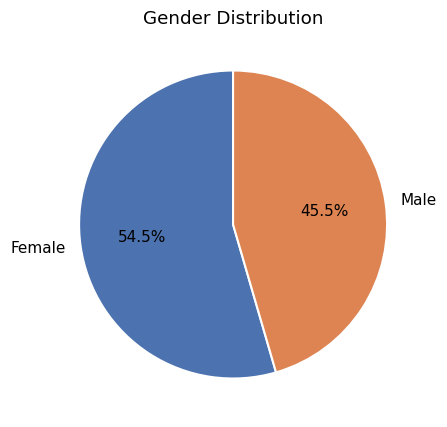

In [7]:
gender_counts = df["Gender"].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    colors=CLUSTER_PALETTE[:2],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
plt.title("Gender Distribution")
plt.show()

## 3. Data Cleaning

In [8]:
df_clean = df.drop(columns=["CustomerID"])
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Female,20,32,68
1,Male,64,39,30
2,Female,50,42,42
3,Male,48,59,60
4,Male,30,77,64


## 4. Encode Categorical Variable (Gender)

In [9]:
le = LabelEncoder()
df_clean["Gender"] = le.fit_transform(df_clean["Gender"])
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,20,32,68
1,1,64,39,30
2,0,50,42,42
3,1,48,59,60
4,1,30,77,64


## 5. Feature Scaling

In [10]:
features = df_clean.columns.tolist()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[features])
scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-0.913708,-1.618214,-0.793181,0.600629
1,1.094442,1.965149,-0.505574,-0.803055
2,-0.913708,0.824988,-0.382313,-0.359786
3,1.094442,0.662108,0.316163,0.305117
4,1.094442,-0.803813,1.055726,0.452873


## 6. Dimensionality Reduction using PCA

In [11]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,-1.642665,-1.132233
1,1.909913,0.333233
2,0.794426,-0.957322
3,0.288404,1.017206
4,-0.781253,1.563374


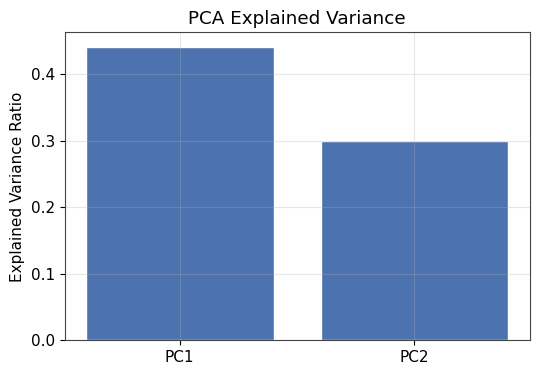

In [12]:
explained = pca.explained_variance_ratio_
plt.figure(figsize=(6, 4))
plt.bar(["PC1", "PC2"], explained, color=PRIMARY_COLOR, edgecolor="white")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.show()

## 7. Elbow Method to Find Optimal K

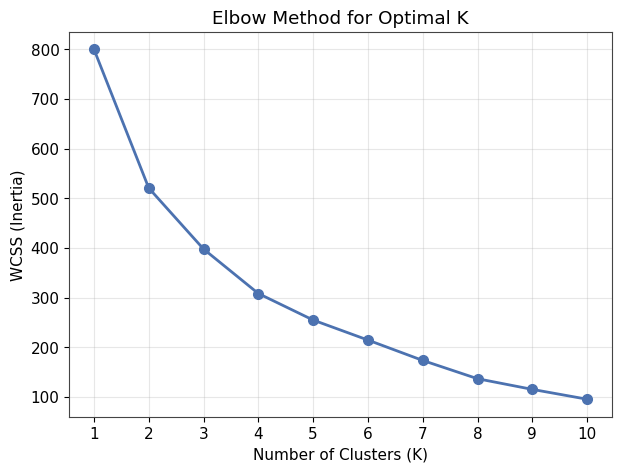

In [13]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_range, wcss, marker="o", color=PRIMARY_COLOR, linewidth=2, markersize=7)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.xticks(list(k_range))
plt.show()

Based on the elbow curve above, the rate of decrease in WCSS slows down noticeably
around **K = 5**, which we select as the optimal number of clusters.

## 8. Apply K-Means Clustering

In [14]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

df_clean["Cluster"] = cluster_labels
pca_df["Cluster"] = cluster_labels
df_clean.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,20,32,68,4
1,1,64,39,30,0
2,0,50,42,42,0
3,1,48,59,60,2
4,1,30,77,64,2


## 9. Visualize the Clusters

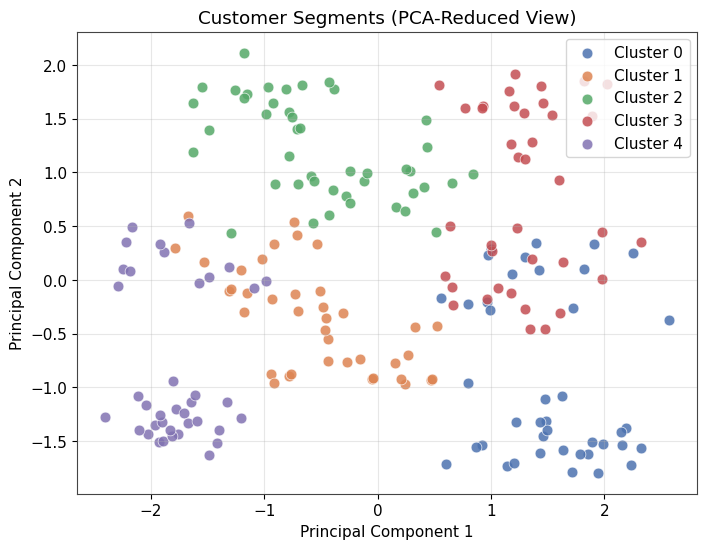

In [15]:
plt.figure(figsize=(8, 6))
for cluster_id in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster_id]
    plt.scatter(
        subset["PC1"], subset["PC2"],
        s=60, alpha=0.85,
        color=CLUSTER_PALETTE[cluster_id],
        label=f"Cluster {cluster_id}",
        edgecolor="white", linewidth=0.5,
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (PCA-Reduced View)")
plt.legend()
plt.show()

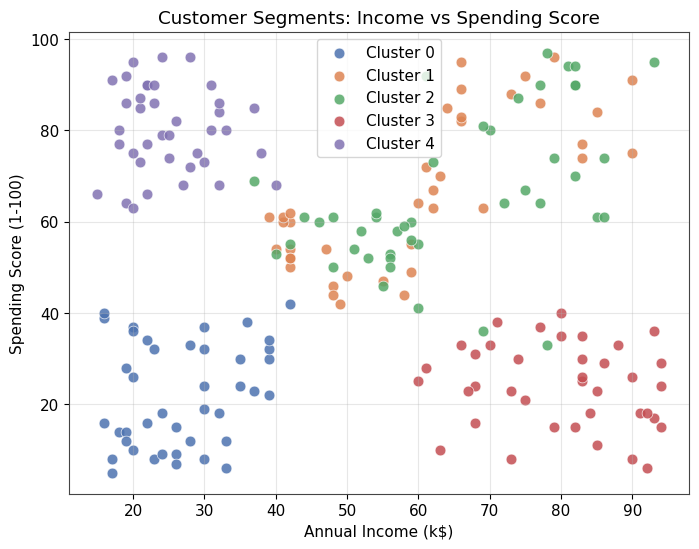

In [16]:
plt.figure(figsize=(8, 6))
for cluster_id in sorted(df_clean["Cluster"].unique()):
    subset = df_clean[df_clean["Cluster"] == cluster_id]
    plt.scatter(
        subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
        s=60, alpha=0.85,
        color=CLUSTER_PALETTE[cluster_id],
        label=f"Cluster {cluster_id}",
        edgecolor="white", linewidth=0.5,
    )

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments: Income vs Spending Score")
plt.legend()
plt.show()

## 10. 3D Cluster Visualization

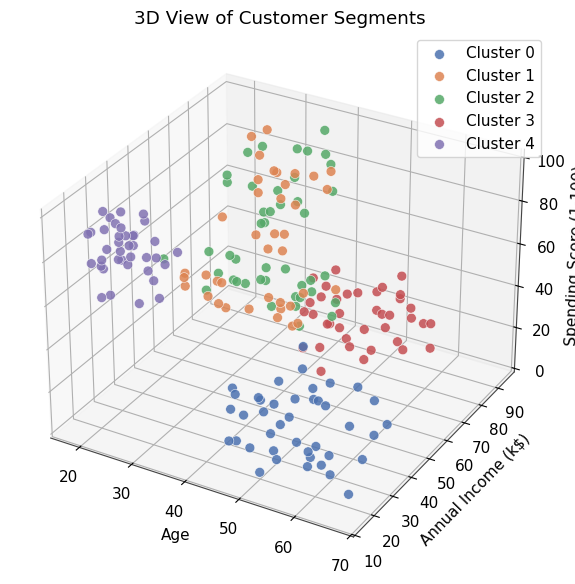

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for cluster_id in sorted(df_clean["Cluster"].unique()):
    subset = df_clean[df_clean["Cluster"] == cluster_id]
    ax.scatter(
        subset["Age"], subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
        s=50, alpha=0.85,
        color=CLUSTER_PALETTE[cluster_id],
        label=f"Cluster {cluster_id}",
        edgecolor="white", linewidth=0.4,
    )

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")
ax.set_title("3D View of Customer Segments")
ax.legend()
plt.show()

## 11. Cluster Profiles

In [18]:
cluster_summary = df_clean.groupby("Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
cluster_summary["Count"] = df_clean["Cluster"].value_counts().sort_index()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,54.4,26.8,22.2,41
1,36.4,59.6,66.4,39
2,36.6,64.7,65.8,44
3,47.8,79.9,24.0,38
4,23.6,25.1,80.1,38


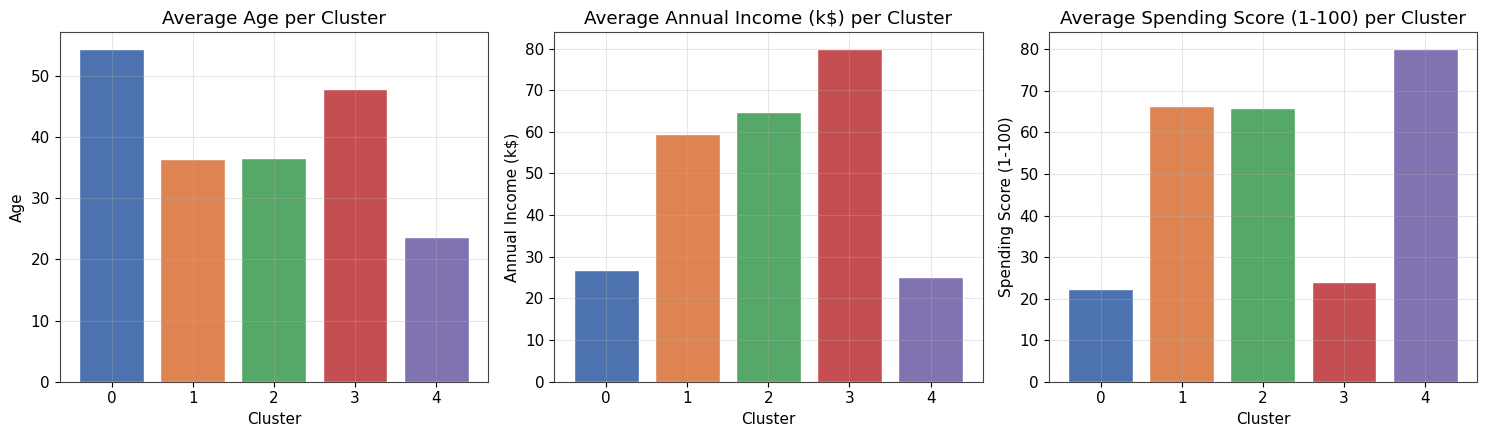

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        cluster_summary.index.astype(str), cluster_summary[metric],
        color=CLUSTER_PALETTE[: len(cluster_summary)],
        edgecolor="white",
    )
    ax.set_title(f"Average {metric} per Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

## 12. Interpreting Clusters as Business Personas

In [20]:
income_median = df_clean["Annual Income (k$)"].median()
spending_median = df_clean["Spending Score (1-100)"].median()

def assign_persona(row):
    high_income = row["Annual Income (k$)"] >= income_median
    high_spending = row["Spending Score (1-100)"] >= spending_median

    if high_income and high_spending:
        return "Premium Target Customers"
    if high_income and not high_spending:
        return "Cautious High Earners"
    if not high_income and high_spending:
        return "Impulsive Budget Spenders"
    if not high_income and not high_spending:
        return "Budget-Conscious Customers"
    return "Average Customers"

cluster_summary["Persona"] = cluster_summary.apply(assign_persona, axis=1)
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count,Persona
Cluster,,,,,
0,54.4,26.8,22.2,41,Budget-Conscious Customers
1,36.4,59.6,66.4,39,Premium Target Customers
2,36.6,64.7,65.8,44,Premium Target Customers
3,47.8,79.9,24.0,38,Cautious High Earners
4,23.6,25.1,80.1,38,Impulsive Budget Spenders


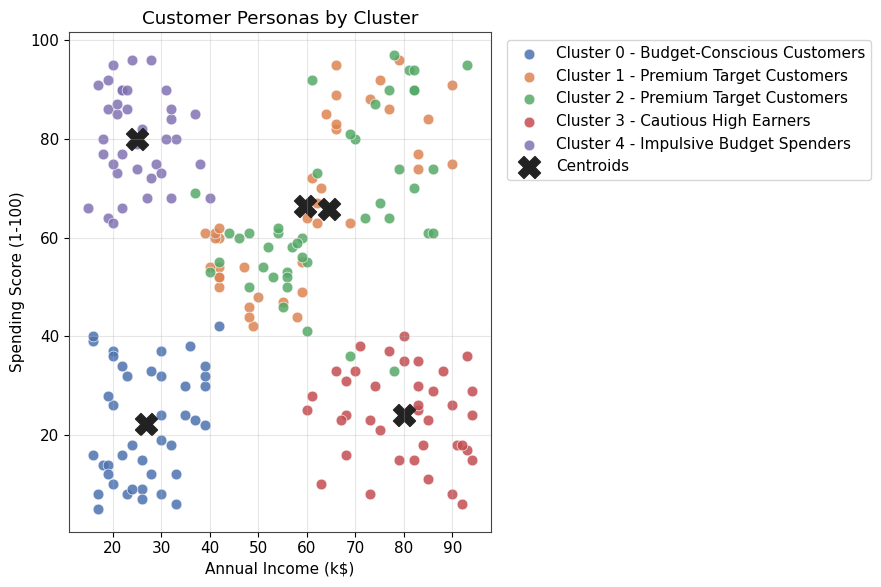

In [21]:
plt.figure(figsize=(9, 6))
for cluster_id in sorted(df_clean["Cluster"].unique()):
    subset = df_clean[df_clean["Cluster"] == cluster_id]
    persona = cluster_summary.loc[cluster_id, "Persona"]
    plt.scatter(
        subset["Annual Income (k$)"], subset["Spending Score (1-100)"],
        s=60, alpha=0.85,
        color=CLUSTER_PALETTE[cluster_id],
        label=f"Cluster {cluster_id} - {persona}",
        edgecolor="white", linewidth=0.5,
    )

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=features)
plt.scatter(
    centers_df["Annual Income (k$)"], centers_df["Spending Score (1-100)"],
    s=250, marker="X", color=CENTROID_COLOR, label="Centroids",
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Personas by Cluster")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 13. Business Recommendations

| Persona | Typical Profile | Suggested Strategy |
|---|---|---|
| Premium Target Customers | High income, high spending | Loyalty programs, premium products, personalized offers |
| Cautious High Earners | High income, low spending | Targeted promotions, value-driven messaging to unlock spending |
| Impulsive Budget Spenders | Low income, high spending | Discount bundles, flexible payment options |
| Budget-Conscious Customers | Low income, low spending | Low-cost essentials, clearance deals |
| Average Customers | Mid income, mid spending | Cross-selling, seasonal campaigns |

This segmentation enables the business to design targeted marketing strategies,
optimize promotional budgets, and improve customer retention by treating each
segment according to its actual behavior rather than a one-size-fits-all approach.